<a href="https://colab.research.google.com/github/tanercc/python-colab/blob/dev/tjk_to_Predict_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install -q mysql-connector-python
!pip install pandas tensorflow

Get TJK DB

In [18]:
import mysql.connector as connection
import pandas as pd
try:
    mydb = connection.connect(host="taner.web.tr", database = 'tanerweb_tjk',user="tanerweb_tjk", passwd="Ka9jVjRJRtRW",use_pure=True)
    query = """
SELECT
`atlar`.`KOD` AS `code`,
`atlar`.`ADKUCUK` AS `name`,
`kosular`.`GRUP_EN` AS `group`,
`atlar`.`ANNE` AS `mother`,
`atlar`.`BABA` AS `father`,
`kosular`.`TARIH` AS `date`,
`hipodrom`.`AD` AS `hipname`,
`hipodrom`.`KOD` AS `hipcode`,
`kosular`.`ActiveClass` AS `surface`,
COALESCE(CASE WHEN `kosular`.`PIST` = 'cim' THEN `hava`.`CIM_EN` ELSE `hava`.`KUM_EN` END, 'Normal') AS `ground`,
`kosular`.`RACENO` AS `raceno`,
`atlar`.`KILO` + `atlar`.`FAZLAKILO` AS `weight`,
`atlar`.`JOKEYADI` AS `jockey`,
`kosular`.`MESAFE` AS `metre`,
`atlar`.`DERECE` AS `time`,
COALESCE(`atlar`.`SONUC`, (SELECT COUNT(NO) FROM `atlar` AS `atsay` WHERE `atlar`.`TARIHKOD`=`atsay`.`TARIHKOD` AND `atlar`.`HIPODROMKOD`=`atsay`.`HIPODROMKOD` AND `atlar`.`KOSUNO`=`atsay`.`KOSUNO`)) AS `pos`
FROM `atlar`
LEFT JOIN `hava` ON (`atlar`.`TARIHKOD` = `hava`.`TARIHKOD` AND `atlar`.`HIPODROMKOD` = `hava`.`HIPODROMKOD`)
LEFT JOIN `kosular` ON (`kosular`.`TARIHKOD` = `atlar`.`TARIHKOD` AND `atlar`.`HIPODROMKOD` = `kosular`.`HIPODROMKOD` AND `atlar`.`KOSUNO` = `kosular`.`NO`)
LEFT JOIN `hipodrom` ON `hipodrom`.`KOD` = `atlar`.`HIPODROMKOD`
WHERE `atlar`.`TARIHKOD` > 20200904
AND `atlar`.`KILO` > 0
AND `atlar`.`KOSMAZ` = 0
AND `atlar`.`GECCIKIS_BOY` = ''
AND `atlar`.`START` > 0
AND `atlar`.`DERECE` > 0
AND `atlar`.`SONUC` > 0
AND `atlar`.`SONUC` < 5
ORDER BY `atlar`.`TARIHKOD` DESC,`atlar`.`HIPODROMKOD`,`atlar`.`KOSUNO`
    """
    #AND `atlar`.`HIPODROMKOD` = 1
    df = pd.read_sql(query,mydb)
    mydb.close() #close the connection
except Exception as e:
    mydb.close()
    print(str(e))

<ipython-input-18-0520a4803543>:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,mydb)


In [19]:
df.head()

,code,name,group,mother,father,date,hipname,hipcode,surface,ground,raceno,weight,jockey,metre,time,pos
0,106207,Felix Perla,3 Years Old Thoroughbreds,COPY CAT,KANEKO,29/03/2025,Adana Yeşiloba Hipodromu,1,sand,Good Going,1,58.8,SELİM KAYA,1400,90.56,4
1,104086,Mothers Love Mea,3 Years Old Thoroughbreds,LADY KENTUCKY (USA),GOOD CURRY,29/03/2025,Adana Yeşiloba Hipodromu,1,sand,Good Going,1,56.0,MÜSLÜM ÇELİK,1400,89.36,1
2,103537,Star Gate,3 Years Old Thoroughbreds,LABEZERIN,TRAPPE SHOT (USA),29/03/2025,Adana Yeşiloba Hipodromu,1,sand,Good Going,1,55.2,NİZAMETTİN DEMİR,1400,90.53,3
3,104207,Berhudar,3 Years Old Thoroughbreds,KEYSE TUGEN,BODYGUARD HERO (USA),29/03/2025,Adana Yeşiloba Hipodromu,1,grass,Good Going,2,58.0,MEHMET SALİH ÇELİK,1300,77.87,1
4,105563,My Sixth Sense,3 Years Old Thoroughbreds,FLICK THE SWITCH,SEVENTH SENSE,29/03/2025,Adana Yeşiloba Hipodromu,1,grass,Good Going,2,58.0,ERCAN ÇANKAYA,1300,79.21,4


In [20]:
#df.to_csv("data-output.csv")

In [21]:
# Drop unnecessary columns (names, codes, date, etc.)
df = df.drop(columns=["code", "hipname", "hipcode", "date", "raceno", "pos"])

# Optional: Handle nulls
df = df.dropna()

df.head()

,name,group,mother,father,surface,ground,weight,jockey,metre,time
0,Felix Perla,3 Years Old Thoroughbreds,COPY CAT,KANEKO,sand,Good Going,58.8,SELİM KAYA,1400,90.56
1,Mothers Love Mea,3 Years Old Thoroughbreds,LADY KENTUCKY (USA),GOOD CURRY,sand,Good Going,56.0,MÜSLÜM ÇELİK,1400,89.36
2,Star Gate,3 Years Old Thoroughbreds,LABEZERIN,TRAPPE SHOT (USA),sand,Good Going,55.2,NİZAMETTİN DEMİR,1400,90.53
3,Berhudar,3 Years Old Thoroughbreds,KEYSE TUGEN,BODYGUARD HERO (USA),grass,Good Going,58.0,MEHMET SALİH ÇELİK,1300,77.87
4,My Sixth Sense,3 Years Old Thoroughbreds,FLICK THE SWITCH,SEVENTH SENSE,grass,Good Going,58.0,ERCAN ÇANKAYA,1300,79.21


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from sklearn.metrics import mean_absolute_error

# Fix numerics
numeric_cols = ['weight', 'metre', 'time']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
df = df.dropna(subset=numeric_cols)

# Categorical columns
cat_cols = ['name', 'group', 'mother', 'father', 'surface', 'ground', 'jockey']
num_cols = ['weight', 'metre']

# Features and label
X = df[cat_cols + num_cols]
y = df["time"]

# Preprocessing: OneHot for categoricals, Scale numerics
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", StandardScaler(), num_cols)
])

X_processed = preprocessor.fit_transform(X)

# Initialize KFold cross-validation
kf = KFold(n_splits=16, shuffle=True, random_state=42)

# Initialize list to store MAE for each fold
mae_scores = []

model = None

# K-fold cross-validation
for train_index, val_index in kf.split(X_processed):
    X_train, X_val = X_processed[train_index], X_processed[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Build Neural Network model
    if model is None:
        model = Sequential([
            Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.1),
            Dense(1)
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss=MeanSquaredError(),
            metrics=['mae']
        )

    # Train the model
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=8,
        batch_size=16,
        verbose=1
    )

    # Evaluate the model on validation set and store MAE
    y_val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_val_pred)
    mae_scores.append(mae)
    print(f"Fold MAE: {mae:.2f} seconds")

# Calculate the average MAE across all folds
avg_mae = np.mean(mae_scores)
print(f"\nAverage MAE across all folds: {avg_mae:.2f} seconds")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
6307/6307 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 3115.4639 - mae: 38.9678 - val_loss: 11.0951 - val_mae: 2.5604
Epoch 2/8
6307/6307 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 80.7312 - mae: 7.0835 - val_loss: 9.6404 - val_mae: 2.3797
Epoch 3/8
6307/6307 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 75.0209 - mae: 6.8278 - val_loss: 8.3530 - val_mae: 2.1841
Epoch 4/8
6307/6307 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 74.0097 - mae: 6.8011 - val_loss: 10.1396 - val_mae: 2.4645
Epoch 5/8
6307/6307 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 71.3650 - mae: 6.6724 - val_loss: 9.9122 - val_mae: 2.4258
Epoch 6/8
6307/6307 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 68.8821 - mae: 6.5660 - val_loss: 8.1137 - val_mae: 2.0693
Epoch 7/8
2077/6307 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 67.4343 - mae: 6.4725

KeyboardInterrupt: 

In [ ]:
# Save the model (full model: architecture + weights + optimizer)
model.save("race_time_model-v2.keras")
print("✅ Model saved as race_time_model.keras")

In [ ]:
import joblib

# Save the preprocessor pipeline
joblib.dump(preprocessor, "preprocessor-v2.pkl")
print("✅ Preprocessor saved as preprocessor.pkl")

In [ ]:
# Create a new input DataFrame
new_data = pd.DataFrame([{
    "name": "Beautiful Mina",
    "group": "3 Years Old Thoroughbreds",
    "mother": "Mİ BOMBON",
    "father": "SUPER SAVER (USA)",
    "surface": "sand",
    "ground": "Good Going",
    "weight": 57.0,
    "jockey": "AHMET ÇELİK",
    "metre": 1400
}])

# Preprocess and predict
new_processed = preprocessor.transform(new_data)
predicted_time = model.predict(new_processed)
print("Predicted Time:", round(predicted_time[0][0], 2), "seconds")


In [28]:
from tensorflow.keras.models import load_model
import joblib
import pandas as pd

# Load the model and preprocessor
model_new = load_model("race_time_model-v2.keras")
preprocessor_new = joblib.load("preprocessor-v2.pkl")

# Example: New input
new_data = pd.DataFrame([{
    "name": "Beautiful Mina",
    "group": "3 Years Old Thoroughbreds",
    "mother": "Mİ BOMBON",
    "father": "SUPER SAVER (USA)",
    "surface": "sand",
    "ground": "Good Going",
    "weight": 57.0,
    "jockey": "AHMET ÇELİK",
    "metre": 1400
}])

# Transform and predict
new_processed = preprocessor_new.transform(new_data)
predicted_time = model_new.predict(new_processed)

print("🏁 Predicted Time:", round(predicted_time[0][0], 2), "seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
🏁 Predicted Time: 89.58 seconds


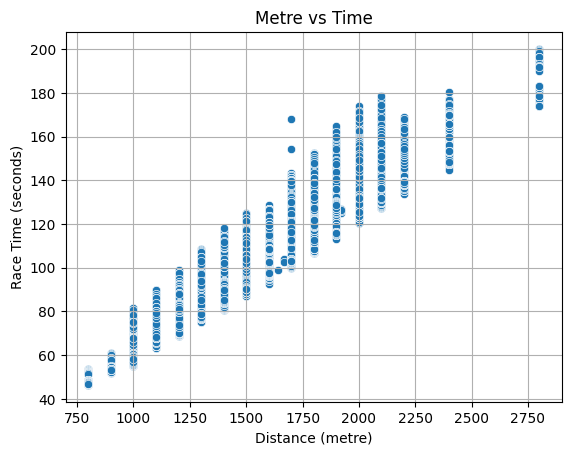

In [27]:
#Calculate the nonlineer effect of metre on time
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=df["metre"], y=df["time"])
plt.title("Metre vs Time")
plt.xlabel("Distance (metre)")
plt.ylabel("Race Time (seconds)")
plt.grid(True)
plt.show()

673/673 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


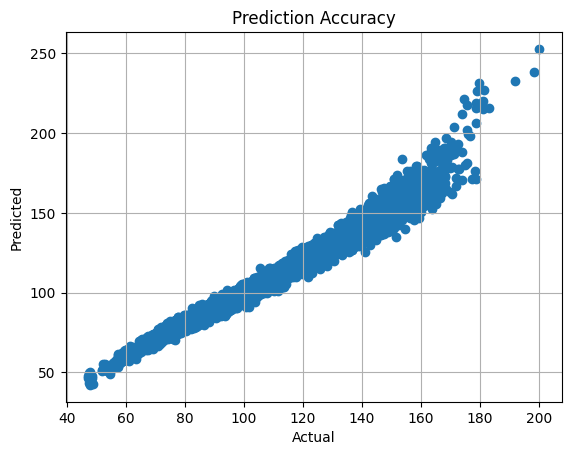

In [29]:
#Plot predicted vs actual times:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction Accuracy")
plt.grid(True)